Quietly install packages for working with point cloud files.

In [1]:
%%capture
! pip install laspy 

# Loading and visualizing the dataset

In [2]:
import geopandas as gpd
import laspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns


In [3]:
pd.set_option('display.width', 1000)

# Field inventory

In [4]:
field_survey = gpd.read_file("data/field_survey.geojson")


print("Shape of the DataFrame:", field_survey.shape)
print("\nHead of the DataFrame:")
print(field_survey.head())

print("\nColumn Data Types:")
print(field_survey.dtypes)

print("\nDescriptive Statistics:")
print(field_survey.describe())

missing_data = pd.DataFrame({
    "Column": field_survey.columns,
    "Count": field_survey.isnull().sum(),
    "Percentage": round((field_survey.isnull().sum() / len(field_survey)) * 100, 2)
})

missing_data.reset_index(drop=True, inplace=True)
print("\nMissing Values Summary:")
print(missing_data.to_string(index=False))


Shape of the DataFrame: (3602, 11)

Head of the DataFrame:
   plot  tree_no species    d1    d2    dbh   age  height  angle comment                        geometry
0   1.0      1.0   Birch  47.2  46.2  46.70   NaN    26.5    0.0    None   POINT (547075.84 6450425.243)
1   1.0      2.0   Aspen  27.9  29.1  28.50   NaN     NaN    0.0    None  POINT (547074.299 6450419.542)
2   1.0      3.0     Fir  12.1  13.0  12.55   NaN     NaN    0.0    None  POINT (547077.454 6450419.994)
3   1.0      4.0   Aspen  23.3  23.7  23.50  69.0    27.4    0.0    None   POINT (547078.211 6450419.02)
4   1.0      5.0   Aspen  23.2  31.3  27.25   NaN     NaN    0.0    None  POINT (547074.669 6450415.573)

Column Data Types:
plot         float64
tree_no      float64
species       object
d1           float64
d2           float64
dbh          float64
age          float64
height       float64
angle        float64
comment       object
geometry    geometry
dtype: object

Descriptive Statistics:
              plot   

In [5]:
field_survey['plot'] = field_survey['plot'].astype('category')
field_survey['tree_no'] = field_survey['tree_no'].astype('int16')
field_survey['angle'] = field_survey['angle'].astype('uint8')

In [6]:
species_counts = field_survey.value_counts("species").reset_index()
species_counts["percentage"] = round((species_counts["count"] / species_counts["count"].sum()) * 100, 2)
species_counts

,species,count,percentage
0,Spruce,1144,31.76
1,Birch,676,18.77
2,Fir,663,18.41
3,Aspen,598,16.60
4,Tilia,370,10.27
5,Alder,121,3.36
6,Willow,28,0.78
7,Elm,1,0.03
8,Pine,1,0.03


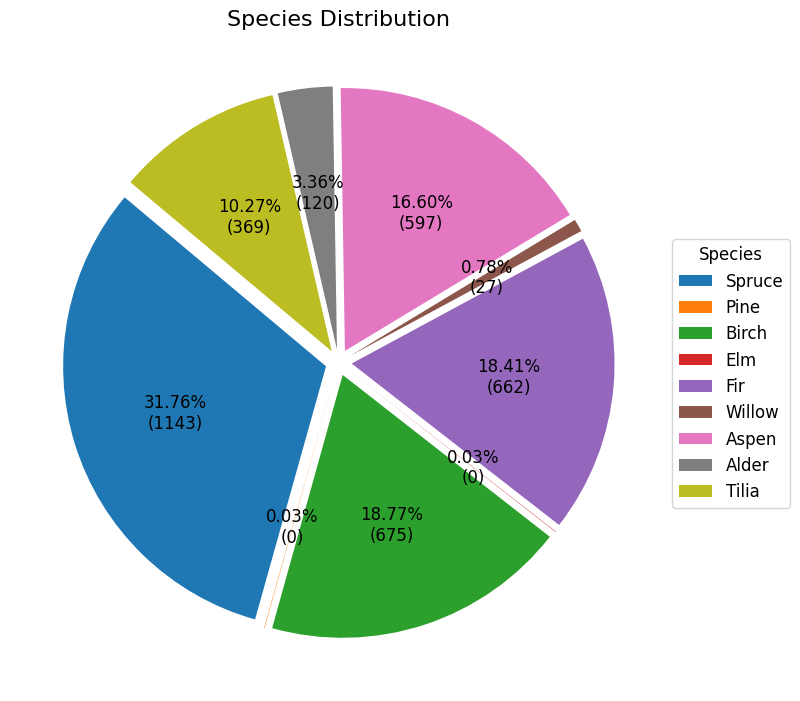

In [7]:
desired_order = ["Spruce", "Pine", "Birch", "Elm", "Fir", "Willow", "Aspen", "Alder", "Tilia"]
species_counts = species_counts.set_index("species").loc[desired_order].reset_index()

explode = [0.05] * len(species_counts["count"]) 


plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    species_counts["count"],  
    explode=explode, 
    startangle=140,
    autopct=lambda p: f'{p:.2f}%\n({int(p * species_counts["count"].sum() / 100)})',  
    textprops={'fontsize': 12}
)

plt.title("Species Distribution", fontsize=16)
plt.legend(wedges, species_counts["species"],
           title="Species", loc="upper right", 
           bbox_to_anchor=(1.2, 0.7), fontsize=12, 
           title_fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
31.76+0.03+18.41

50.2

In [10]:
conifiers = {"Spruce", "Fir", "Pine"}
species_counts["type"] = species_counts["species"].map(lambda x: "Coniferous" if x in conifiers else "Deciduous")
species_counts = species_counts.sort_values(by="count", ascending=False)

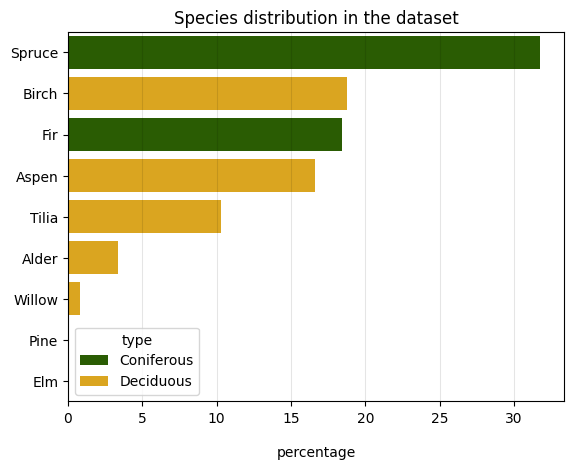

In [19]:
ax = sns.barplot(
    data=species_counts,
    x="percentage",
    y="species",
    hue="type",
    dodge=False,
    hue_order=["Coniferous", "Deciduous"],
    palette=["#2A5C03", "#DAA520"],
    saturation=1,
)
ax.set_title("Species distribution in the dataset")
ax.grid(axis="x", color="black", alpha=0.1)
plt.xlabel("percentage", labelpad=15)
plt.ylabel("")    
plt.show()


In [19]:
field_survey["type"] = field_survey["species"].map(lambda x: "Coniferous" if x in conifiers else "Deciduous")

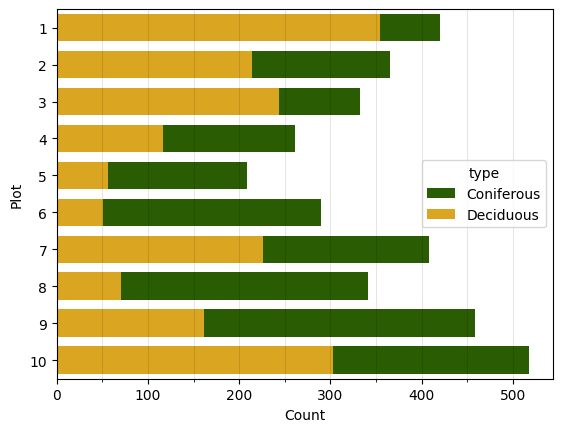

In [20]:
ax = sns.histplot(
    data=field_survey,
    y="plot",
    discrete=True,
    hue="type",
    hue_order=["Coniferous", "Deciduous"],
    palette=["#2A5C03", "#DAA520"],
    multiple="stack",
    shrink=0.75,
    alpha=1,
    lw=0,
)
ax.set_ylim(10.5, 0.5)
ax.set_ylabel("Plot")
ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(50))
ax.grid(axis="x", color="black", alpha=0.1)
ax.grid(axis="x", which="minor", color="black", alpha=0.1)

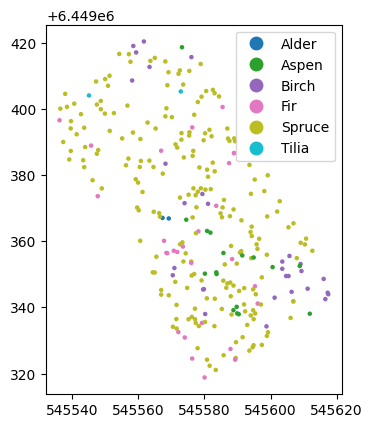

In [29]:
ax = field_survey.query("plot == 6").plot(
    column="species",
    legend=True,
    s=5,
    aspect="equal",
)

<Figure size 2000x1500 with 0 Axes>

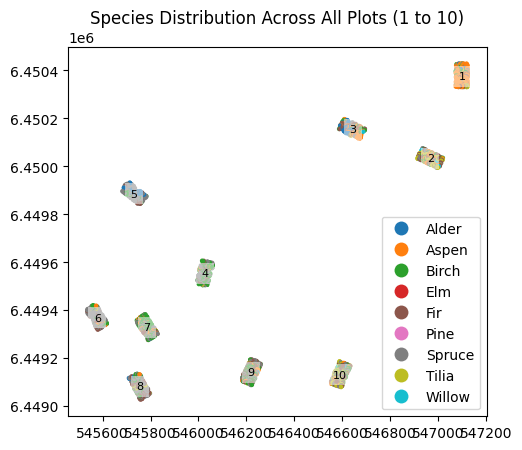

In [ ]:
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(20, 15))  # Adjust width (12) and height (8) as needed

# Plot the field survey data
ax = field_survey.plot(
    column="species",  # Color points by species
    legend=True,
    s=5,
    aspect="equal",
)

# Add plot numbers as annotations
for plot_number in range(1, 11):
    subset = field_survey.query(f"plot == {plot_number}")
    if not subset.empty:
        # Mark the center of each plot
        x_center = subset.geometry.x.mean()
        y_center = subset.geometry.y.mean()
        ax.text(
            x_center,
            y_center,
            str(plot_number),
            fontsize=8,
            color="black",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"),
        )

# Set title
ax.set_title("Species Distribution Across All Plots (1 to 10)")

# Display the plot
plt.show()


# RGB images

In [10]:
with rasterio.open("data/ortho/plot_01.tif") as f:
    p1 = f.read()

with rasterio.open("data/ortho/plot_06.tif") as f:
    p6 = f.read()

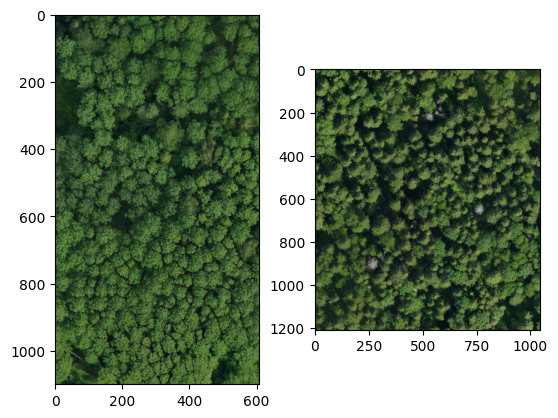

In [11]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(np.rollaxis(p1, 0, 3) / 255.0, clim=(0, 255))
axes[1].imshow(np.rollaxis(p6, 0, 3) / 255.0, clim=(0, 255));

# Point clouds

In [12]:
plot1 = laspy.read("data/als/plot_01.las").xyz
plot6 = laspy.read("data/als/plot_06.las").xyz

for cloud in (plot1, plot6):
    cloud -= cloud.min(axis=0, keepdims=True)

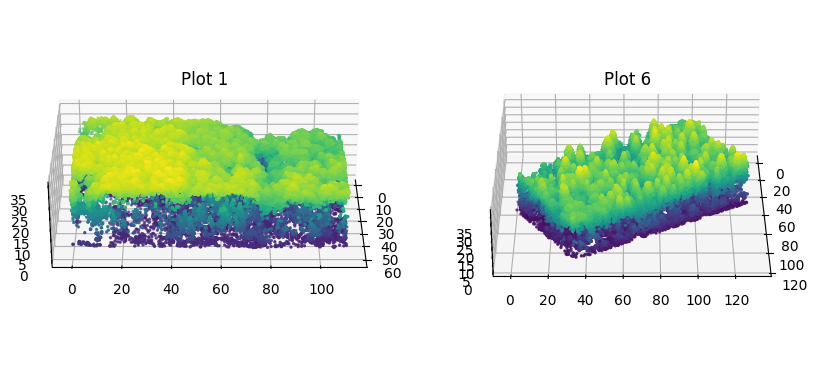

In [13]:
fig = plt.figure(figsize=(10, 5))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")

ax0.scatter(
    *plot1.swapaxes(0, 1),
    c=plot1[:, 2],
    s=2,
)

ax1.scatter(
    *plot6.swapaxes(0, 1),
    c=plot6[:, 2],
    s=2,
)

ax0.view_init(elev=30, azim=0)
ax1.view_init(elev=30, azim=0)

ax0.set_title("Plot 1", y=0.83)
ax1.set_title("Plot 6", y=0.83)

for ax in (ax0, ax1):
    ax.set_aspect("equal")

# Colorized point cloud

In [14]:
cloud6 = laspy.read("data/als/plot_06.las").xyz

In [16]:
%%time
with rasterio.open("data/ortho/plot_06.tif") as f:
    colors = f.sample(xy=cloud6[:, :2])
    colors = np.stack(list(colors))

CPU times: total: 10.3 s
Wall time: 35.8 s


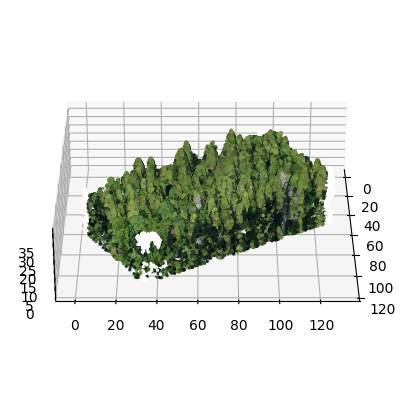

In [17]:
normalized = cloud6 - cloud6.min(axis=0, keepdims=True)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(
    *normalized.swapaxes(0, 1),
    c=colors / 255.0,
    s=2,
)
ax.view_init(elev=30, azim=0)
ax.set_aspect("equal")